--- 

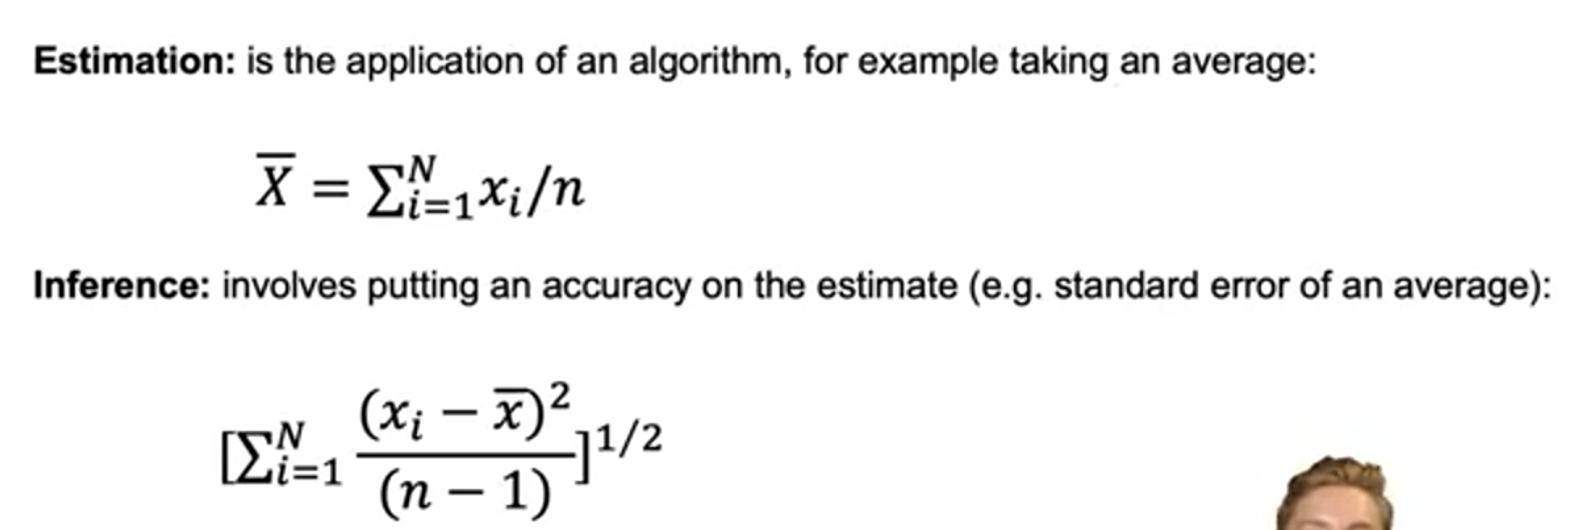

Machine Learning and Statistics Inference are similar


# TỔNG HỢP BÀI GIẢNG: STATISTICAL CONCEPTS IN MACHINE LEARNING & DATA-DRIVEN DECISION-MAKING

## 1. Mục Tiêu Khóa Học (Learning Goals)
* **Estimation vs. Inference:** Phân biệt ước lượng điểm và suy diễn thống kê.
* **Parametric vs. Non-parametric Modeling:** Mô hình có tham số và phi tham số.
* **Common Statistical Distributions:** Các phân phối xác suất phổ biến trong thực tế.
* **Frequentist vs. Bayesian Statistics:** Phân biệt trường phái tần suất và trường phái Bayes.

---

## 2. Điểm Khác Biệt Cốt Lõi: Estimation vs. Statistical Inference

| Khái niệm | Định nghĩa & Mục đích | Ví dụ trong Dự đoán Rời bỏ (Customer Churn) |
| :--- | :--- | :--- |
| **Estimation** *(Ước lượng)* | Tính toán một giá trị cụ thể (**Point Estimate**) từ dữ liệu mẫu để ước tính tham số quần thể (ví dụ: tính giá trị trung bình $\bar{x}$, tính trọng số $\beta$). | *"Mỗi năm gắn bó thêm giúp giảm 20% nguy cơ khách hàng rời bỏ."* (Chỉ đưa ra con số ước lượng duy nhất là 20%). |
| **Statistical Inference** *(Suy diễn thống kê)* | Mở rộng ngoài ước lượng điểm: tìm hiểu phân phối tiềm ẩn (**underlying population distribution**), đo lường sai số chuẩn (**Standard Error**), tính khoảng tin cậy (**Confidence Interval**), và kiểm định ý nghĩa thống kê (**Statistical Significance** / p-value). | Kiểm tra xem con số 20% kia có đáng tin cậy hay không:<br>- **TH1:** Khoảng tin cậy 95% rơi vào `[19%, 21%]` $\rightarrow$ Rất tự tin kết luận hiệu quả là khoảng 20%.<br>- **TH2:** Khoảng tin cậy 95% rơi vào `[-10%, 50%]` $\rightarrow$ Độ bất định quá cao, không có ý nghĩa thống kê (hiệu quả thực tế có thể âm hoặc dương). |

---

## 3. Mối Quan Hệ Giữa Machine Learning và Thống Kê
* Cả Machine Learning (ML) và Thống kê suy diễn đều dùng **dữ liệu mẫu** để suy luận về **quần thể thực tế** và cơ chế sinh dữ liệu (**Data-Generating Process**).
* **Mô hình tuyến tính** là một ví dụ điển hình về hàm xấp xỉ phân phối đồng thời giữa biến $X$ và nhãn $y$.
* **Hai trường phái mô hình ML:**
  1. *Interpretable ML (Cần Statistical Inference):* Tập trung hiểu sâu về bản chất tham số, tác động riêng lẻ của từng đặc trưng (Feature Importances, P-values, Confidence Intervals).
  2. *Black-box ML (Tập trung thuần túy vào Prediction / Estimates):* Chỉ quan tâm đến kết quả dự đoán $\hat{y}$ (ví dụ: Deep Learning, Random Forest) mà không cần bóc tách phân phối của từng biến.

---

# TỔNG HỢP BÀI GIẢNG: KHÁM PHÁ DỮ LIỆU (EDA) TRÊN TẬP DỮ LIỆU TELCO CUSTOMER CHURN

## 1. Giới Thiệu Tập Dữ Liệu (Dataset Overview)
* **Nguồn:** Tập dữ liệu Telco Customer Churn từ IBM Cognos Analytics.
* **Đối tượng phân tích:** Dữ liệu thuê bao điện thoại được lưu trong DataFrame `df_phone`.
* **Các thuộc tính chính:**
  * `churn_value`: Biến mục tiêu nhị phân (1 = Rời bỏ dịch vụ, 0 = Tiếp tục ở lại).
  * `payment`: Hình thức thanh toán (Credit Card, Bank Withdrawal, Mailed Check,...).
  * `months` (hoặc `tenure_months`): Số tháng gắn bó của khách hàng.
  * `gb_mon`: Dung lượng dữ liệu sử dụng hàng tháng (GB).
  * `total_revenue`: Tổng doanh thu từ khách hàng.
  * `cltv`: Customer Lifetime Value (Giá trị vòng đời khách hàng).
  * `monthly_charge`: Mức cước phí hàng tháng.

---

## 2. Các Bước Trực Quan Hóa & Phát Hiện Nghiệp Vụ (EDA Insights)

### a. Phân tích Tỷ lệ Rời bỏ theo Hình thức Thanh toán (Bar Plot)
* **Kỹ thuật:** Vẽ biểu đồ cột với trục hoành $x$ là `payment`, trục tung $y$ là `churn_value`.
* **Phát hiện:** Khách hàng thanh toán qua Thẻ tín dụng (Credit Card) có tỷ lệ rời bỏ thấp hơn đáng kể so với những người thanh toán bằng séc qua thư (Mailed Check) hoặc rút tiền ngân hàng.

### b. Gom nhóm Thời gian sử dụng bằng `pd.cut` (Discretization / Binning)
* **Kỹ thuật:** Cắt biến liên tục `months` thành 5 khoảng giá trị đều nhau (ví dụ: [0, 15], (15, 30],...) để tạo biến định loại phục vụ cho Bar Plot.
* **Phát hiện:** Khách hàng mới (số tháng sử dụng thấp) có xu hướng rời bỏ cao vượt trội so với khách hàng lâu năm.

### c. Phân tích Tương quan Đa biến với `sns.pairplot`
* **Kỹ thuật:** Vẽ lưới biểu đồ cho tập con các đặc trưng: `months`, `gb_mon`, `total_revenue`, `cltv`.
* **Phân lớp:** Dùng tham số `hue='churn_value'` (Xanh dương = Ở lại, Xanh lá = Rời bỏ).
* **Phát hiện:** Phân phối lệch rõ rệt ở thời gian gắn bó; khách hàng rời bỏ tập trung dày đặc ở các mốc thời gian đầu.

### d. Phân tích Mật độ Hai biến với Hexbin Plot (`sns.jointplot`)
* **Kỹ thuật:** Trực quan hóa mối quan hệ giữa `months` và `monthly_charge` bằng ô lục giác (`kind='hex'`).
* **Phát hiện:** Mật độ tập trung ở 2 cực: Khách hàng gắn bó lâu với mức cước cao, và một nhóm khách hàng mới rời bỏ nhanh dù trả cước phí hàng tháng khá cao.